#  BoxPlot_1 : Epsilon improvement



In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import pickle
from typing import List, Dict, Any
import sys
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
import itertools

In [3]:
def vargha_delaney_A(x, y):
    """
    Compute Vargha–Delaney A effect size.
    A = 0.5 means no effect, >0.5 means x tends to be larger.
    """
    n1, n2 = len(x), len(y)
    ranked = pd.Series(np.concatenate([x, y])).rank()
    r1 = ranked[:n1].sum()
    A = (r1 / n1 - (n1 + 1) / 2.0) / n2
    return A

In [5]:

#stats_df = pd.read_csv("/content/RP_self_repair/notebook/dumb_strong_regressors.csv")
stats_df = pd.read_csv("mc_regressor.csv")

SIZE = (6, 7)

filtered = []

for method in stats_df["Method"].unique():
  selected_method = stats_df[stats_df["Method"] == method]
  if method.endswith("neighbours"):
    filtered.append(selected_method)
    continue
  selected_method = selected_method.iloc[::20]
  filtered.append(selected_method)
stats_df = pd.concat(filtered, ignore_index=True).reset_index(drop=True)

/tmp/ipykernel_15446/4007722458.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Method_prefix"] = filtered_df["Method"].str.split(r'[-_]').str[0]


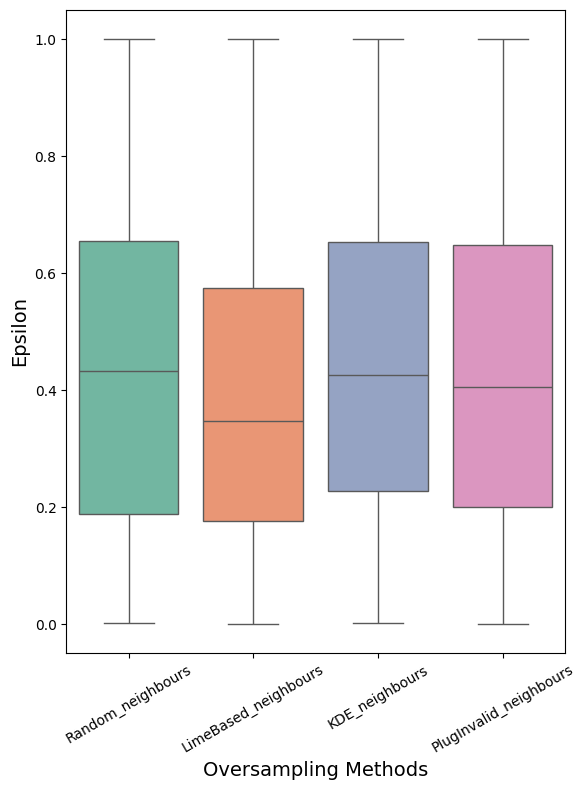

In [6]:
# Epsilons over oversampling methods

# Compute Epsilon
stats_df["Epsilon"] = abs(stats_df["Neighbours_optimized"] - stats_df["Neighbours_validation"])

# Filter only desired methods
methods_to_show = ["Random_neighbours", "LimeBased_neighbours", "KDE_neighbours", "PlugInvalid_neighbours"]
filtered_df = stats_df[stats_df["Method"].isin(methods_to_show)]

# Extract prefix (before first underscore or hyphen)
filtered_df["Method_prefix"] = filtered_df["Method"].str.split(r'[-_]').str[0]

# Create color palette
unique_prefixes = filtered_df["Method_prefix"].unique()
palette = dict(zip(unique_prefixes, sns.color_palette("Set2", len(unique_prefixes))))

# Plot boxplot
plt.figure(figsize=(6, 8))
sns.boxplot(data=filtered_df, x="Method", y="Epsilon", hue="Method_prefix", palette=palette, dodge=False, legend=False)

plt.xlabel("Oversampling Methods", fontsize=14)
plt.ylabel("Epsilon", fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [7]:
# Filter to get only the neighbors data
neighbours_stats = stats_df[stats_df["Method"].str.endswith("neighbours")].reset_index(drop="True")


=== Mann–Whitney U Test and Vargha–Delaney Effect Size ===


,Method 1,Method 2,Mann-Whitney p-value,Vargha–Delaney A
0,Random_neighbours,KDE_neighbours,2.793926e-01,0.486994
1,Random_neighbours,LimeBased_neighbours,7.890811e-09,0.383228
2,KDE_neighbours,LimeBased_neighbours,3.920827e-06,0.403212


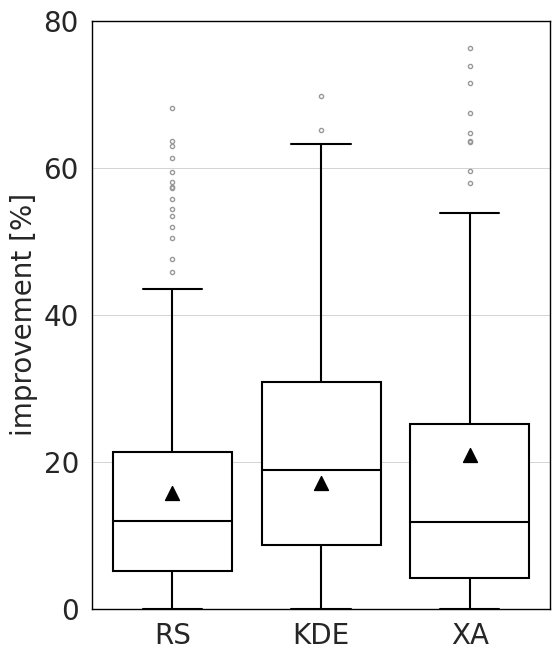

In [8]:
PLOT_FIG = "improvement_1.pdf"
#PLOT_FIG = "improvement_2.pdf"

# --- Compute Epsilon and Relative Error ---
neighbours_stats["Epsilon"] = abs(
    neighbours_stats["Neighbours_optimized"] - neighbours_stats["Neighbours_validation"]
)

baseline_eps = neighbours_stats.loc[
    neighbours_stats["Method"] == "target-20-neighbours", "Epsilon"
].reset_index(drop=True)

repeats = len(neighbours_stats) // len(baseline_eps) + 1
baseline_aligned = pd.concat([baseline_eps] * repeats, ignore_index=True)[:len(neighbours_stats)]

neighbours_stats["Relative error"] = 100 * (baseline_aligned - neighbours_stats["Epsilon"])

# --- Filter only selected methods ---
methods_to_show = ["Random_neighbours", "KDE_neighbours", "LimeBased_neighbours"]
filtered_df = neighbours_stats[neighbours_stats["Method"].isin(methods_to_show)].copy()

# --- Extract prefix for coloring ---
filtered_df["Method_prefix"] = filtered_df["Method"].str.split(r'[-_]').str[0]
filtered_df = filtered_df[filtered_df["Relative error"] >= 0].copy()

# --- Compute means for triangles ---
means = filtered_df.groupby("Method")["Relative error"].mean()

# ================================
#  Statistical Comparison Section
# ================================

results = []
for m1, m2 in itertools.combinations(methods_to_show, 2):
    x = filtered_df.loc[filtered_df["Method"] == m1, "Relative error"]
    y = filtered_df.loc[filtered_df["Method"] == m2, "Relative error"]

    u_stat, p_val = mannwhitneyu(x, y, alternative="less")
    A = vargha_delaney_A(x.values, y.values)

    results.append({
        "Method 1": m1,
        "Method 2": m2,
        "Mann-Whitney p-value": p_val,
        "Vargha–Delaney A": A
    })

stats_table = pd.DataFrame(results)
print("\n=== Mann–Whitney U Test and Vargha–Delaney Effect Size ===")
display(stats_table)

# ================================
#  Plot
# ================================

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})
plt.figure(figsize=SIZE)

# --- White boxplots with black outlines ---
sns.boxplot(
    data=filtered_df,
    x="Method",
    y="Relative error",
    color="white",
    linewidth=1.5,
    fliersize=3,
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
)

# --- Overlay mean triangles ---
for i, method in enumerate(methods_to_show):
    if method in means.index:
        plt.scatter(
            i, means.loc[method],
            color="black", marker="^", s=100, zorder=5
        )

# --- Axis labels and styling ---
plt.ylabel("improvement [%]")
plt.xlabel("")
plt.grid(True, which="major", axis="y", color="lightgray", linewidth=0.7)

# --- Add frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

ax.set_ylim(0, 80)
plt.yticks(range(0, 81, 20))

# --- Map x labels ---
label_map = {
    "Random_neighbours": "RS",
    "PlugInvalid_neighbours": "PI",
    "KDE_neighbours": "KDE",
    "LimeBased_neighbours": "XA"
}
plt.xticks(
    ticks=range(len(methods_to_show)),
    labels=[label_map[m] for m in methods_to_show],
    rotation=0
)

plt.tight_layout()
plt.savefig(PLOT_FIG)
plt.show()


=== Mean Improvement per Method (filtered ≥ 0) ===
Random_neighbours        : 15.81%
KDE_neighbours           : 17.13%
LimeBased_neighbours     : 20.91%


/tmp/ipykernel_15446/1740764771.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=0)


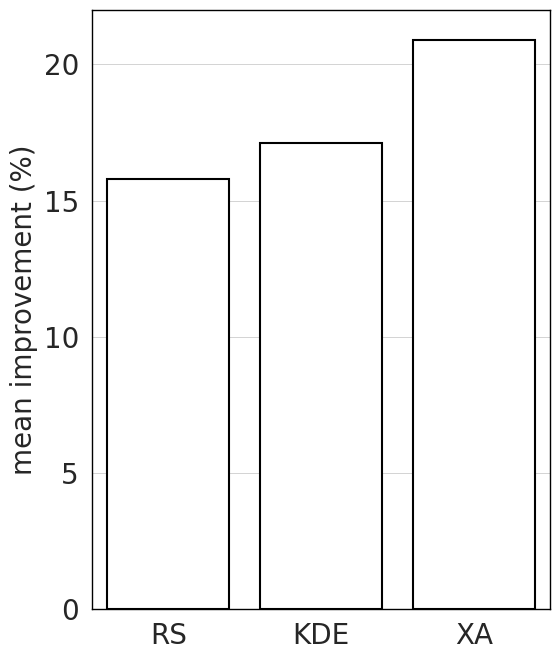

In [9]:
PLOT_FIG = "mean_improvement_1.pdf"
#PLOT_FIG = "mean_improvement_2.pdf"

filtered_df = neighbours_stats[neighbours_stats["Method"].isin(methods_to_show)].copy()
filtered_df = filtered_df[filtered_df["Relative error"] >= 0].copy()

# Mean improvement per method
mean_improvement = (
    filtered_df.groupby("Method", as_index=False)["Relative error"].mean()
)

# Desired order (keep only those present)
desired_order = [
    "Random_neighbours",
    "KDE_neighbours",
    "LimeBased_neighbours",
]
mean_improvement = mean_improvement[mean_improvement["Method"].isin(desired_order)]

# Enforce order on x-axis
mean_improvement["Method"] = pd.Categorical(
    mean_improvement["Method"], categories=desired_order, ordered=True
)
mean_improvement = mean_improvement.sort_values("Method")

print("\n=== Mean Improvement per Method (filtered ≥ 0) ===")
for _, row in mean_improvement.iterrows():
    print(f"{row['Method']:<25s}: {row['Relative error']:.2f}%")

# Minimal white style with grid
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})
plt.figure(figsize=SIZE)

# White bars with black edges
ax = sns.barplot(
    data=mean_improvement,
    x="Method",
    y="Relative error",
    color="white",
    edgecolor="black",
    linewidth=1.5
)

# Subtle horizontal grid
plt.grid(True, which="major", axis="y", color="lightgray", linewidth=0.7)

# Add frame (all spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

ax.set_ylim(0, 22)
plt.yticks(range(0, 22, 5))

# Labels
plt.xlabel("")
plt.ylabel("mean improvement (%)")
plt.title("")

# Map x labels
label_map = {
    "Random_neighbours": "RS",
    "LimeBased_neighbours": "XA",
    "PlugInvalid_neighbours": "PI",
    "KDE_neighbours": "KDE",
}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=0)

plt.tight_layout()
plt.savefig(PLOT_FIG)
plt.show()

# BoxPlot_2: Success probability of scs



=== Success Rate (SCS) Improvement for threshold 0.9 ===
Random_neighbours        : 11.00%
KDE_neighbours           : 10.33%
LimeBased_neighbours     : 11.33%


/tmp/ipykernel_15446/756310614.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=0)


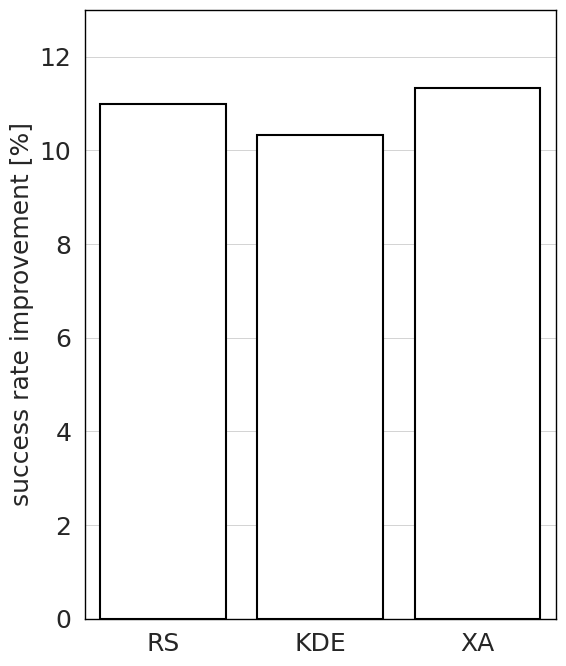

In [10]:
#PLOT_FIG = "scs_improvement_1.pdf"
PLOT_FIG = "scs_improvement_2.pdf"

# --- Thresholds ---
# scs_thresholds = [0.2, 0.4, 0.6, 0.8]
scs_thresholds = [0.9]

# --- Compute SCS thresholds (% above) ---
threshold_group = neighbours_stats.groupby("Method", as_index=False).size()
for threshold in scs_thresholds:
    temp = (
        neighbours_stats.assign(above=lambda d: d["Neighbours_validation"] >= threshold)
        .groupby("Method", as_index=False)
        .agg(above_count=("above", "sum"), total=("Neighbours_validation", "count"))
    )
    threshold_group[f"scs_tr_{threshold}"] = temp["above_count"] / temp["total"] * 100.0

# --- Keep only selected methods, in order ---
methods_to_show = ["Random_neighbours", "KDE_neighbours", "LimeBased_neighbours"]
threshold_group = threshold_group[threshold_group["Method"].isin(methods_to_show)].copy()
threshold_group["Method"] = pd.Categorical(threshold_group["Method"], categories=methods_to_show, ordered=True)
threshold_group = threshold_group.sort_values("Method")

# --- Build a tidy df for plotting (single threshold shown) ---
thr = scs_thresholds[0]
plot_df = threshold_group[["Method", f"scs_tr_{thr}"]].rename(columns={f"scs_tr_{thr}": "SCS"})

print(f"\n=== Success Rate (SCS) Improvement for threshold {thr} ===")
for _, row in plot_df.iterrows():
    print(f"{row['Method']:<25s}: {row['SCS']:.2f}%")

# --- Minimal white style with grid + frame (same as previous) ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

plt.figure(figsize=SIZE)
ax = sns.barplot(
    data=plot_df,
    x="Method",
    y="SCS",
    color="white",
    edgecolor="black",
    linewidth=1.5
)

ax.set_ylim(0, 13)
plt.yticks(range(0, 13, 2))

# --- Labels, grid, frame ---
plt.ylabel("success rate improvement [%]")
plt.xlabel("")
plt.title("")  # keep minimal, no title
plt.grid(True, which="major", axis="y", color="lightgray", linewidth=0.7)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

# --- Map x labels to RS, XA, PI, KDE ---
label_map = {
    "Random_neighbours": "RS",
    "LimeBased_neighbours": "XA",
    "PlugInvalid_neighbours": "PI",
    "KDE_neighbours": "KDE",
}
ax.set_xticklabels([label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=0)

plt.tight_layout()
plt.savefig(PLOT_FIG)
plt.show()

In [12]:
#### MAIN FUNCTION ###
import pickle
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec


def analyze_success_from_pkl_with_process_results(pkl_path: str, threshold: float, test_name: str) -> None:
    # create output directory
    out_dir = f"visualization/{test_name}"
    os.makedirs(out_dir, exist_ok=True)

    df = pd.read_csv(pkl_path)

    # --- success-rate per Method ---
    grouped = (
        df.assign(above=lambda d: d["Neighbours_validation"] >= threshold)
          .groupby("Method", as_index=False)
          .agg(above_count=("above", "sum"), total=("Neighbours_validation", "count"))
    )

    grouped["success_rate_%"] = grouped["above_count"] / grouped["total"] * 100.0

    grouped = grouped.sort_values("success_rate_%", ascending=False).reset_index(drop=True)

    print("Success rate per 'Method':")
    for _, row in grouped.iterrows():
        print(f"- {row['Method']}: {int(row['above_count'])}/{int(row['total'])} = {row['success_rate_%']:.2f}%")

    # --- salva CSV ---
    csv_path = os.path.join(out_dir, f"success_rates_threshold_{str(threshold).replace('.', '_')}.csv")
    grouped.to_csv(csv_path, index=False)
    print(f"Saved summary CSV: {csv_path}")

    # --- figura: barplot + tabella (stile simile al tuo esempio) ---
    fig = plt.figure(figsize=(18, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])

    # Subplot 1: barplot
    ax_plot = plt.subplot(gs[0])
    sns.barplot(data=grouped, x="Method", y="success_rate_%", ax=ax_plot)
    ax_plot.set_title(f"Success Rate per Method — threshold = {threshold}")
    ax_plot.set_xlabel("Method")
    ax_plot.set_ylabel("Success rate sopra soglia (%)")
    ax_plot.set_xticklabels(ax_plot.get_xticklabels(), rotation=30, ha="right")
    ax_plot.grid(True, axis='y', linestyle=':', alpha=0.7)

    # Annotazioni barre
    for i, p in enumerate(ax_plot.patches):
        rate = grouped.loc[i, "success_rate_%"]
        a = int(grouped.loc[i, "above_count"])
        t = int(grouped.loc[i, "total"])
        ax_plot.text(
            p.get_x() + p.get_width()/2,
            p.get_height(),
            f"{rate:.1f}%\n({a}/{t})",
            ha="center", va="bottom", fontsize=9
        )

    # Subplot 2: tabella
    display_cols = ["Method", "above_count", "total", "success_rate_%"]
    df_table = grouped[display_cols].copy()
    df_table.rename(columns={
        "Method": "Method",
        "above_count": "Above",
        "total": "Total",
        "success_rate_%": "Success Rate (%)"
    }, inplace=True)

    ax_table = plt.subplot(gs[1])
    ax_table.axis('off')
    table = ax_table.table(
        cellText=df_table.values,
        colLabels=df_table.columns,
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.4)

    # save
    img_path = os.path.join(out_dir, f"success_rates_threshold_{str(threshold).replace('.', '_')}.png")
    plt.tight_layout()
    plt.savefig(img_path, dpi=300)
    plt.close()

    print(f"Saved bar plot: {img_path}")

if __name__ == "__main__":
    path = 'dumb_strong_regressors.csv'
    threshold = 0.5
    test_name = "test_1"

    analyze_success_from_pkl_with_process_results(path, 0.4, "test_1")

Success rate per 'Method':
- LimeBased_neighbours: 354/600 = 59.00%
- KDE_neighbours: 325/600 = 54.17%
- target-20-neighbours: 315/600 = 52.50%
- Random_neighbours: 302/600 = 50.33%
- PlugInvalid_neighbours: 295/600 = 49.17%
Saved summary CSV: visualization/test_1/success_rates_threshold_0_4.csv


/tmp/ipykernel_15446/1641950058.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_plot.set_xticklabels(ax_plot.get_xticklabels(), rotation=30, ha="right")


Saved bar plot: visualization/test_1/success_rates_threshold_0_4.png


# BoxPlot_3: Execution Time


## main function --> use this to plot (VERSIONE PROF)

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load results from your CSV (produced by the benchmark script) ---
df = pd.read_csv("oversampling_times_repeated.csv")

# Keep only successful runs
df_ok = df[df["OK"] == True].copy()

# --- Keep ONLY RS, KDE, XA, in that order ---
methods_to_show = [
    "RandomOversampling",   # RS
    "KDEOversampling",      # KDE
    "LimeBasedOversampling" # XA
]

# Filter rows and set categorical order (drop any other methods)
df_ok = df_ok[df_ok["Method"].isin(methods_to_show)].copy()
df_ok["Method"] = pd.Categorical(df_ok["Method"], categories=methods_to_show, ordered=True)

# --- Minimal white style ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    data=df_ok,
    x="Method",
    y="ExecutionTime",
    order=methods_to_show,
    color="white",
    linewidth=1.5,
    fliersize=3,
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
)

# --- Log scale ---
ax.set_yscale("log")

# --- Map x labels ---
label_map = {
    "RandomOversampling": "RS",
    "KDEOversampling": "KDE",
    "LimeBasedOversampling": "XA",
}
ax.set_xticklabels([label_map[m] for m in methods_to_show], rotation=0)

# --- Grid + frame ---
plt.xlabel("")
plt.ylabel("execution time [s]")
plt.title("")
plt.grid(True, which="major", axis="y", color="lightgray", linewidth=0.7)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("time_logscale.pdf")
plt.show()

print("🖼️ Boxplot salvato in: time_logscale_RS_KDE_XA.pdf")

FileNotFoundError: [Errno 2] No such file or directory: 'oversampling_times_repeated.csv'

# Versione nostra

In [ ]:
import time
import csv
import math
import logging
import pandas as pd
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")


def run_benchmark_all_methods(n_runs: int = 10, n_samples: int = 30):
    # --- Inizializza la pipeline
    p = Pipeline(
        training_dataset_path="/content/RP_self_repair/notebook/dataset1000.csv",
        test_data_path="/content/RP_self_repair/notebook/dataset1000.csv",
        points_regressor=100,
        n_data_to_verify=10
    )

    # Stesse configurazioni per tutti i test
    first_30 = p.test_set.head(30)

    # Metodi da testare
    methods = [
        RandomOversampling,
        LimeBasedOversampling,
        KDEOversampling,
        PlugInvalid
    ]

    rows = []
    logging.info(f"🏁 Avvio benchmark: {len(methods)} metodi × {n_runs} run ciascuno")

    for cls in methods:
        logging.info(f"\n⚙️ Metodo: {cls.__name__}")
        for run_id in range(1, n_runs + 1):
            t0 = time.perf_counter()
            ok = True
            err_msg = ""
            try:
                if cls == LimeBasedOversampling:
                    instance = cls(p.regressor)
                    instance.run_oversampling(df=first_30.copy(), n_samples=n_samples)
                elif cls == PlugInvalid:
                    instance = cls()
                    instance.run_oversampling(df=first_30.copy())
                else:
                    instance = cls()
                    instance.run_oversampling(df=first_30.copy(), n_samples=n_samples)
            except Exception as e:
                ok = False
                err_msg = repr(e)
                logging.exception(f"❌ Errore al run {run_id} per {cls.__name__}")
            t1 = time.perf_counter()

            rows.append({
                "Run": run_id,
                "Method": cls.__name__,
                "ExecutionTime": (t1 - t0) if ok else math.nan,
                "OK": ok,
                "Error": err_msg
            })

            if ok:
                logging.info(f"✅ {cls.__name__} - Run {run_id} completato in {(t1 - t0):.4f} s")

    # --- Salva CSV con TUTTE le misure
    df = pd.DataFrame(rows)
    all_csv = "oversampling_times_repeated.csv"
    df.to_csv(all_csv, index=False)
    print(f"📊 Misure grezze salvate in: {all_csv}")

    # --- Analisi statistica per metodo (ignorando i run falliti)
    df_ok = df[df["OK"]].copy()
    stats = (
        df_ok.groupby("Method")["ExecutionTime"]
        .agg(
            count="count",
            mean="mean",
            std="std",
            var="var",
            min="min",
            q1=lambda s: s.quantile(0.25),
            median="median",
            q3=lambda s: s.quantile(0.75),
            max="max"
        )
        .reset_index()
        .sort_values("mean")
    )
    stats_csv = "oversampling_times_stats.csv"
    stats.to_csv(stats_csv, index=False)
    print(f"📈 Statistiche per metodo salvate in: {stats_csv}")
    print(stats.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

    # --- Boxplot per metodo
    plt.figure()
    # ordina i metodi per media crescente nel boxplot
    order = stats["Method"].tolist()
    df_ok["Method"] = pd.Categorical(df_ok["Method"], categories=order, ordered=True)
    df_ok.boxplot(column="ExecutionTime", by="Method", grid=True)
    plt.suptitle("")  # rimuove titolo extra di pandas
    plt.title("Execution Time per Method (10 run, stesse config)")
    plt.xlabel("Method")
    plt.ylabel("Execution Time [s]")
    plt.xticks(rotation=15)
    plt.tight_layout()
    boxplot_png = "oversampling_times_boxplot.png"
    plt.savefig(boxplot_png, dpi=150)
    plt.close()
    print(f"🖼️ Boxplot salvato in: {boxplot_png}")


if __name__ == "__main__":
    run_benchmark_all_methods(n_runs=10, n_samples=30)


IndentationError: unexpected indent (2627615385.py, line 13)

# BOXPLOT 4: prediction time

📁 regressor_prediction_time.csv → Media: 0.0144, Dev.std: 0.0032
regressor_prediction_time                      0.0144       0.0032
📁 mc_prediction_model.csv → Media: 17.5589, Dev.std: 13.4693
mc_prediction_model                           17.5589      13.4693


/tmp/ipykernel_15446/2111990502.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True)


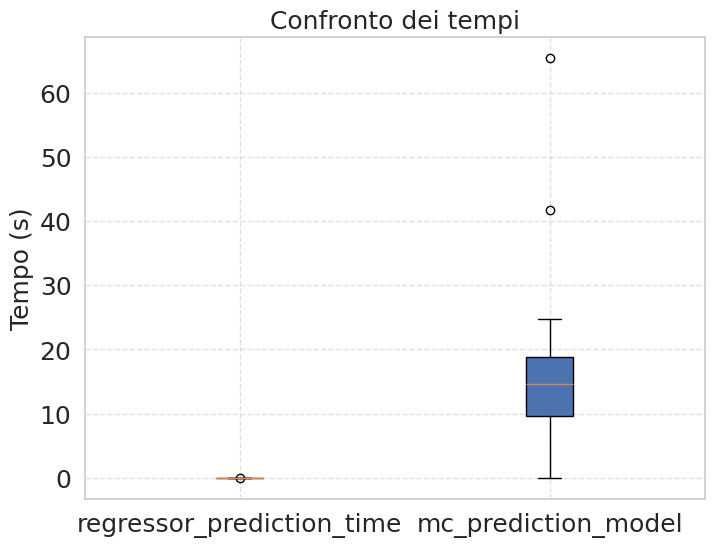

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def compare_boxplots(csv_files: list[str], column_name: str = "PredictionTime_s", save_path: str = "boxplot_compare.png"):
    csv_files = ['regressor_prediction_time.csv', 'mc_prediction_model.csv']
    data = []
    labels = []

    for path in csv_files:
        df = pd.read_csv(path)
        if column_name not in df.columns:
            raise ValueError(f"Colonna '{column_name}' non trovata in {path}")
        values = df[column_name] # Assign values here
        data.append(values)
        labels.append(path.split("/")[-1].replace(".csv", ""))  # nome leggibile

        # stampa statistiche
        mean = values.mean()
        std = values.std()
        print(f"📁 {path} → Media: {mean:.4f}, Dev.std: {std:.4f}")

        # --- Compute and print stats ---
        mean = values.mean()
        std = values[~np.isnan(values)].std() # Calculate std ignoring NaN values
        print(f"{labels[-1]:40s} {mean:12.4f} {std:12.4f}")


    # Crea boxplot multiplo
    plt.figure(figsize=(8, 6))
    plt.boxplot(data, labels=labels, patch_artist=True)
    plt.title("Confronto dei tempi")
    plt.ylabel("Tempo (s)")
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


if __name__ == "__main__":
    # Esempio d’uso
    compare_boxplots(["time_method1.csv", "time_method2.csv"], column_name="PredictionTime_s")